# 高校数学とJulia言語 Day 5 演習問題【解答例】

- 城北中学校・高等学校　中学3年・高校1年
- 夏期講習会III 2026/8/24~2026/8/28
- 担当:清水団

本日のテーマ:確率とシミュレーション

※ 解答例は一例です。別の書き方でも、正しい結果が出ていればOKです!

## 問題1: コイン3枚

コインを3枚投げて「3枚とも表」になる確率を10000回の実験で求め、理論値 $\frac{1}{8}$ と比較しよう。

**解説**:$\frac{1}{2} \times \frac{1}{2} \times \frac{1}{2} = \frac{1}{8} = 0.125$。実験値もこれに近くなります。

In [1]:
# コイン3枚の実験
n = 10000
zenbu_omote = count(1:n) do _
    rand() < 0.5 && rand() < 0.5 && rand() < 0.5
end
println("実験値: $(zenbu_omote / n)")
println("理論値: $(1/8)")

実験値: 0.1267
理論値: 0.125


## 問題2: サイコロの最大値

サイコロを2個投げたときの「大きい方の目」の平均値。

**解説**:大きい方が $k$ になるのは $k^2 - (k-1)^2 = 2k-1$ 通り。理論値は

$$\frac{1 \cdot 1 + 3 \cdot 2 + 5 \cdot 3 + 7 \cdot 4 + 9 \cdot 5 + 11 \cdot 6}{36} = \frac{161}{36} \approx 4.47$$

In [2]:
# 最大値の平均を実験で求める
n = 100000
goukei = sum(max(rand(1:6), rand(1:6)) for _ in 1:n)
println("実験値: $(goukei / n)")
println("理論値: $(161/36)")

実験値: 4.47765
理論値: 4.472222222222222


In [3]:
# 参考:場合の数で理論値を確認(Day3の「全部作る」!)
sum(max(a, b) for a in 1:6, b in 1:6) / 36

4.472222222222222

## 問題3: モンティ・ホール変形版(扉4つ)

扉が4つ(当たり1つ、司会者がハズレを1つ開ける)の場合。

**解説**:
- 変えない:最初に当たる確率のまま $\frac{1}{4} = 0.25$
- 変える:最初ハズレ(確率 $\frac{3}{4}$)なら残り2枚のうち当たりは1枚 → $\frac{3}{4} \times \frac{1}{2} = \frac{3}{8} = 0.375$

扉4つでも「変える」ほうが有利!

In [4]:
# 扉4つのモンティ・ホール
function monty_hall4(change::Bool)
    doors = [1, 2, 3, 4]
    atari = rand(doors)          # 当たりの扉
    choice = rand(doors)         # 最初の選択
    # 司会者は「当たりでも選択でもない」扉を1つ開ける
    host = rand(setdiff(doors, unique([atari, choice])))
    if change
        # 残った2つの扉からランダムに選び直す
        choice = rand(setdiff(doors, [choice, host]))
    end
    return choice == atari
end

n = 100000
println("変えない戦略の勝率: $(count(_ -> monty_hall4(false), 1:n) / n) (理論値 0.25)")
println("変える戦略の勝率:   $(count(_ -> monty_hall4(true), 1:n) / n) (理論値 0.375)")

変えない戦略の勝率: 0.2495 (理論値 0.25)
変える戦略の勝率:   0.37206 (理論値 0.375)


## 問題4: 自由課題(解答例)

**例A:じゃんけんであいこになる確率**

2人でじゃんけんをするとき、あいこになる確率は?(理論値:同じ手を出せばあいこなので $\frac{3}{9} = \frac{1}{3}$)

In [5]:
# じゃんけん:1=グー, 2=チョキ, 3=パー
n = 100000
aiko = count(_ -> rand(1:3) == rand(1:3), 1:n)
println("あいこの確率(実験値): $(aiko / n)")
println("理論値: $(1/3)")

あいこの確率(実験値): 0.33303
理論値: 0.3333333333333333


**例B:ランダムウォーク**

原点から毎ステップ±1をランダムに動くと、1000ステップ後はどのあたりにいる?

    Updating git-repo `https://github.com/ujimushi/PlotsGRBackendFontJaEmoji.jl`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


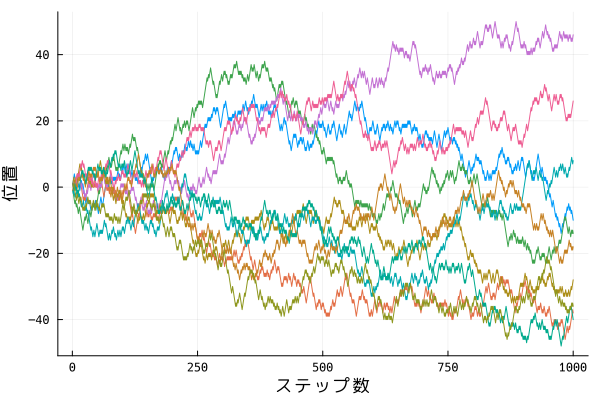

In [6]:
# ランダムウォークの軌跡を10本描いてみる
using Pkg
Pkg.add(url="https://github.com/ujimushi/PlotsGRBackendFontJaEmoji.jl")
using PlotsGRBackendFontJaEmoji, Plots
gr()

p = plot(legend=false, xlabel="ステップ数", ylabel="位置")
for _ in 1:10
    ayumi = cumsum(rand([-1, 1], 1000))
    plot!(p, ayumi, lw=1)
end
p

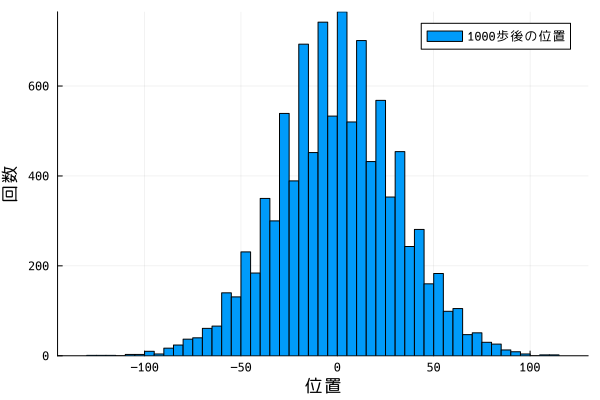

In [7]:
# 1000ステップ後の位置の分布
n = 10000
saigo = [sum(rand([-1, 1], 1000)) for _ in 1:n]
histogram(saigo, bins=50, label="1000歩後の位置", xlabel="位置", ylabel="回数")

## 5日間お疲れさまでした!

自由課題は「問題を自分で作る」ことが一番の勉強です。
くじ引き、カードゲーム、待ち行列……気になる確率があったら、**まず実験**してみてください。